# 1. Binary stars

In [1]:
# Import external packages, and supply settings used throughout the tutorial - you can ignore this cell
import numpy as np
import h5py as h5
from scipy.optimize import fsolve
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import AppLayout, FloatSlider, Play, IntSlider, widgets, HBox, VBox, interact, interactive
from IPython.display import YouTubeVideo
from scripts.BHSummerSchoolUtils import printCompasDetails, get_data, make_interactive_widget

%matplotlib widget

## As we saw on Wednesday, stellar-mass black holes come from massive stars. To understand black hole formation, we need to understand stellar evolution.

### However, the story gets more complicated. Most black holes that we can observe are not isolated: they are in binary star systems and have experienced (or are currently experiencing) binary interactions.

 <img src="data/images/binary_star.jpg" alt="Drawing" style="width: 600px;"/>

## Two major breakthroughs in the last 15 years have really changed our understanding and appreciation of binaries

### - 1st: In 2012, a team of researchers, led by a KU Leuven professor, carefully measured the massive stars in our Galaxy, and found that ~70% have a close binary companion. 

### - Later research found that as you increase the mass of the biggest star, you increase the likelihood that it has even more companions.

 <img src="data/images/sana12.png" alt="Drawing" style="width: 600px;"/>
[Sana et al. 2012]

 <img src="data/images/mds17.png" alt="Drawing" style="width: 600px;"/>
[Moe & Di Stefano 2017]

### - 2nd: In 2015, the LIGO collaboration made the groundbreaking discovery of Gravitational Waves from the merger of two black holes.

 <img src="data/images/ligo_merger.png" alt="Drawing" style="width: 600px;"/>
[Abbott et al. 2016]

## The takeaway: You can't study black holes without accouting for _binarity_. 

## So what is a binary star?

In [2]:
# Constants
G = 6.67430e-11  # Gravitational constant in m^3 kg^-1 s^-2
M_sun = 1.989e30 # Mass of the sun in kg
AU = 1.496e11  # Approximately 1 AU

# Function to calculate gravitational potential at a point (x, y)
def gravitational_potential(x, y, m1, m2, a):
    # Positions of the two stars
    x1, y1 = -a * m2 / (m1 + m2), 0
    x2, y2 = a * m1 / (m1 + m2), 0

    # Distances from the point to each star
    r1 = np.sqrt((x - x1)**2 + (y - y1)**2)
    r2 = np.sqrt((x - x2)**2 + (y - y2)**2)

    # Gravitational potential at the point (x, y)
    omega_sqrd = G*(m1 + m2) / a**3
    phi = -G * (m1 / r1 + m2 / r2) - 0.5*omega_sqrd*(x**2 + y**2)

    return phi

def get_Lagrange_123(m1, m2):
    s0_s1 = [[-1, -1],
             [-1, 1],
             [1, 1]]
    
    alpha = m2/(m1+m2)
    allroots = []
    for (s0, s1) in s0_s1:
        poly = [
            1,
            3 - alpha,
            3 - 2*alpha,
            1 - s1 - alpha*(1 + s0 - s1),
            -2*alpha*s0,
            -alpha*s0
        ]
        roots = np.roots(poly)
        realroot = roots[np.isreal(roots)].real
        allroots.append(realroot)
    
    L1 = allroots[1]
    if m2/m1 > 1:
        L2 = allroots[0]
        L3 = allroots[2]
    else:
        L2 = allroots[2]
        L3 = allroots[0]
    return np.array([L1, L2, L3]).flatten()

def get_positions_rel_to_CoM(m1, m2):
    L1, L2, L3 = get_Lagrange_123(m1, m2)
    posD = -1
    posA = 0
    beta = m1/(m1+m2)
    xCom = -beta
    l1l2l3pDpA_relToCom = np.array([L1, L2, L3, posD, posA]) - xCom
    return l1l2l3pDpA_relToCom

# Function to calculate and plot equipotential surfaces
def plot_equipotential_surfaces(fig, ax, m1, m2, a, scale_factor=3, zoom=1, xcntr=0, num_contours=15, contour_min=0.1, contour_max=2):
    # Define the grid
    x_min, x_max = -scale_factor * a, scale_factor * a
    y_min, y_max = x_min, x_max
    n_points = 500

    x = np.linspace(x_min, x_max, n_points)
    y = np.linspace(y_min, y_max, n_points)
    X, Y = np.meshgrid(x, y)

    # Calculate the potential at each point on the grid
    Z = gravitational_potential(X, Y, m1, m2, a)

    # Find the Lagrangian points
    L1, L2, L3, x1, x2 =  a*get_positions_rel_to_CoM(m1, m2)

    # Calculate potential at Lagrangian points
    phi_L1 = gravitational_potential(L1, 0, m1, m2, a)
    phi_L2 = gravitational_potential(L2, 0, m1, m2, a)
    phi_L3 = gravitational_potential(L3, 0, m1, m2, a)
    if phi_L2 > phi_L3:
        phi_tmp = phi_L2
        phi_L2 = phi_L3
        phi_L3 = phi_tmp
        Ltmp = L2
        L2 = L3
        L3 = Ltmp

    # Plot the equipotential surfaces
    contour_levels = phi_L1*np.linspace(contour_min, contour_max, num_contours, endpoint=True)[::-1]
    ax.contour(X, Y, Z, levels=contour_levels, colors='black', linestyles='-', alpha=0.3)

    # Highlight the equipotential lines passing through Lagrangian points
    ax.contour(X, Y, Z, levels=[ phi_L1, phi_L2, phi_L3 ], colors=['red', 'blue', 'green'], linestyles='--', linewidths=3)

    # Plot the positions of the stars and the Lagrangian points
    ax.scatter([-a * m2 / (m1 + m2), a * m1 / (m1 + m2)], [0, 0], color='white', s=100, edgecolor='black', label='Stars')
    ax.scatter([L1], [0], color='red',   s=300, marker='*', label='L1')
    ax.scatter([L2], [0], color='blue',  s=300, marker='*', label='L2')
    ax.scatter([L3], [0], color='green', s=300, marker='*', label='L3')
    ax.scatter([x1+a/2], [a*np.sqrt(3)/2], color='orange', s=300, marker='*', label='L4')
    ax.scatter([x1+a/2], [-a*np.sqrt(3)/2], color='orange', s=300, marker='*', label='L5')
    
    ax.legend()
    ax.set_title('Equipotential Surfaces around a Binary Star System')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.grid(True)
    default_zoom = 1e11
    ax.set_xlim(-5*default_zoom/zoom + xcntr*default_zoom, 5*default_zoom/zoom + xcntr*default_zoom)
    ax.set_ylim(-5*default_zoom/zoom, 5*default_zoom/zoom)
    #, contour_min=.01, contour_max=2)
    ax.set_aspect('equal')

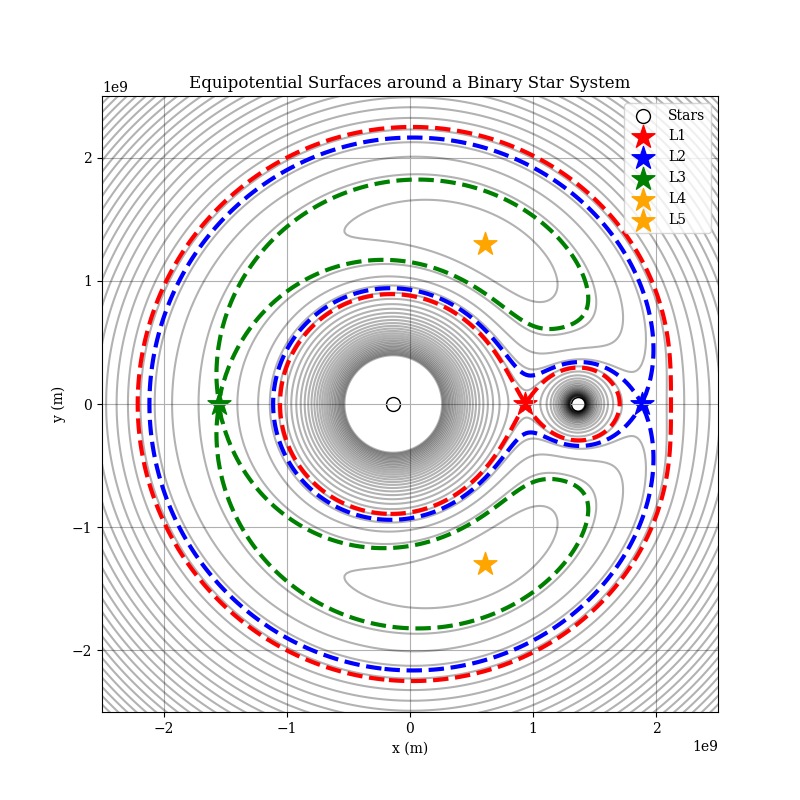

In [3]:
# Example usage
fig, ax = plt.subplots(figsize=(8,8))

m1 = 10*M_sun  # Mass of star 1 (in kg)
m2 = 1*M_sun  # Mass of star 2 (in kg)
a = 0.01*AU  # Separation between the stars (in meters)

# Plot the equipotential surfaces
plot_equipotential_surfaces(fig, ax, m1, m2, a, zoom=200, xcntr=0, num_contours=50)
